In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Global chart style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

# Color constants used throughout
COLOR_YES  = '#E05C5C'   # red   — attrited employees
COLOR_NO   = '#5B8DB8'   # blue  — retained employees
PALETTE    = [COLOR_NO, COLOR_YES]

print('Setup complete.')

Setup complete.


In [2]:
df = pd.read_csv("D:\HR_Analysis\hr_analytics_cleaned.csv")
print('Shape:', df.shape)
df.head(3)

Shape: (1473, 36)


,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AttritionFlag
0,RM611,27,26-35,No,Travel_Rarely,269,Research & Development,5,1,Technical Degree,...,2,1,9,3,3,9,8,0,8,0
1,RM421,29,26-35,No,Travel_Rarely,986,Research & Development,3,4,Medical,...,3,0,10,2,3,10,2,0,7,0
2,RM731,30,26-35,No,Travel_Rarely,153,Research & Development,8,2,Life Sciences,...,3,3,9,4,2,8,7,1,7,0


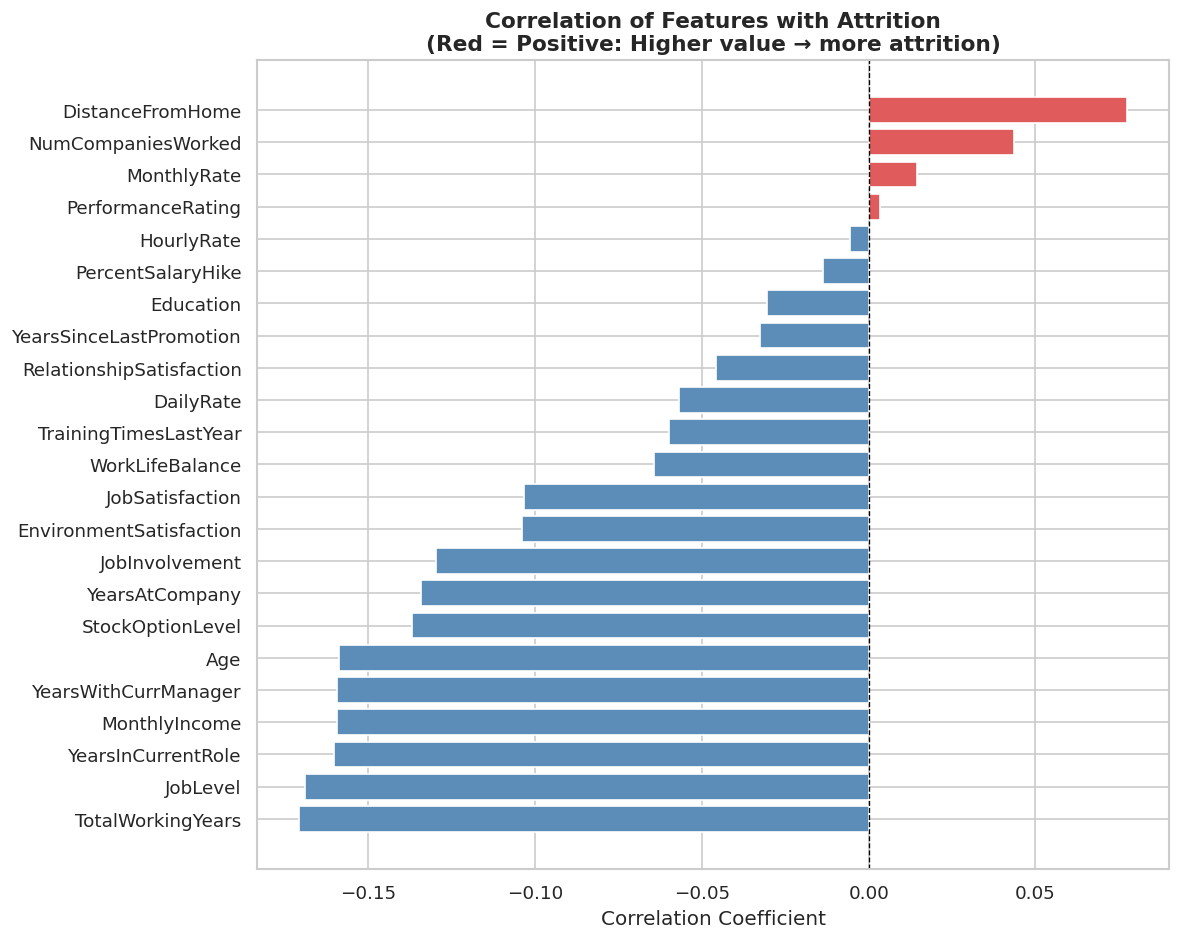

Top 5 features positively correlated with attrition:
DistanceFromHome      0.077585
NumCompaniesWorked    0.043469
MonthlyRate           0.014647
PerformanceRating     0.003268
HourlyRate           -0.005593
Name: AttritionFlag, dtype: float64

Top 5 features negatively correlated with attrition:
TotalWorkingYears      -0.170847
JobLevel               -0.168926
YearsInCurrentRole     -0.160302
MonthlyIncome          -0.159458
YearsWithCurrManager   -0.159421
Name: AttritionFlag, dtype: float64


In [3]:
# Select numeric columns only
numeric_cols = df.select_dtypes(include='number').columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['AttritionFlag', 'EmployeeNumber']]

# Correlation with AttritionFlag
corr = df[numeric_cols + ['AttritionFlag']].corr()['AttritionFlag'].drop('AttritionFlag')
corr_sorted = corr.sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
bar_colors_c = [COLOR_YES if v > 0 else COLOR_NO for v in corr_sorted.values]
bars = ax.barh(corr_sorted.index, corr_sorted.values, color=bar_colors_c, edgecolor='white')

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Correlation of Features with Attrition\n(Red = Positive: Higher value → more attrition)', fontsize=13, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')

plt.tight_layout()
plt.savefig('chart1_correlation.png', bbox_inches='tight')
plt.show()

print('Top 5 features positively correlated with attrition:')
print(corr_sorted.tail(5).sort_values(ascending=False))
print('\nTop 5 features negatively correlated with attrition:')
print(corr_sorted.head(5))

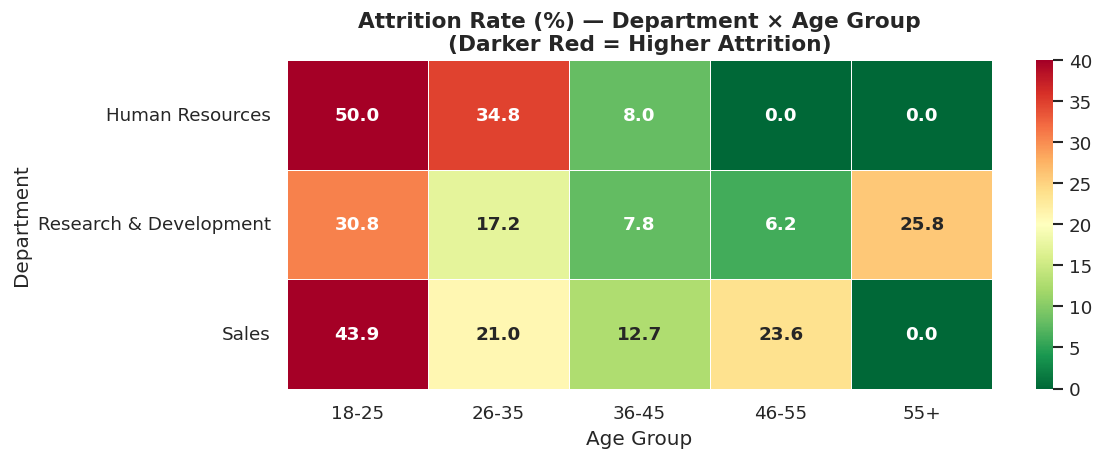

In [4]:
age_order = ['18-25', '26-35', '36-45', '46-55', '55+']

heatmap_data = df.groupby(['Department', 'AgeGroup'])['AttritionFlag'].mean().mul(100).unstack()
heatmap_data = heatmap_data.reindex(columns=age_order)

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    heatmap_data,
    annot=True, fmt='.1f', cmap='RdYlGn_r',
    linewidths=0.5, linecolor='white',
    ax=ax, vmin=0, vmax=40,
    annot_kws={'size': 11, 'weight': 'bold'}
)

ax.set_title('Attrition Rate (%) — Department × Age Group\n(Darker Red = Higher Attrition)', fontsize=13, fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Department')

plt.tight_layout()
plt.savefig('chart2_heatmap_dept_age.png', bbox_inches='tight')
plt.show()